# SNA Practicals

**Submitted By:-** Eshaan R James

**Roll No :-** 16031




In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Q1(A) DIRECTED GRAPH BASED ON IN & OUT DEGREE

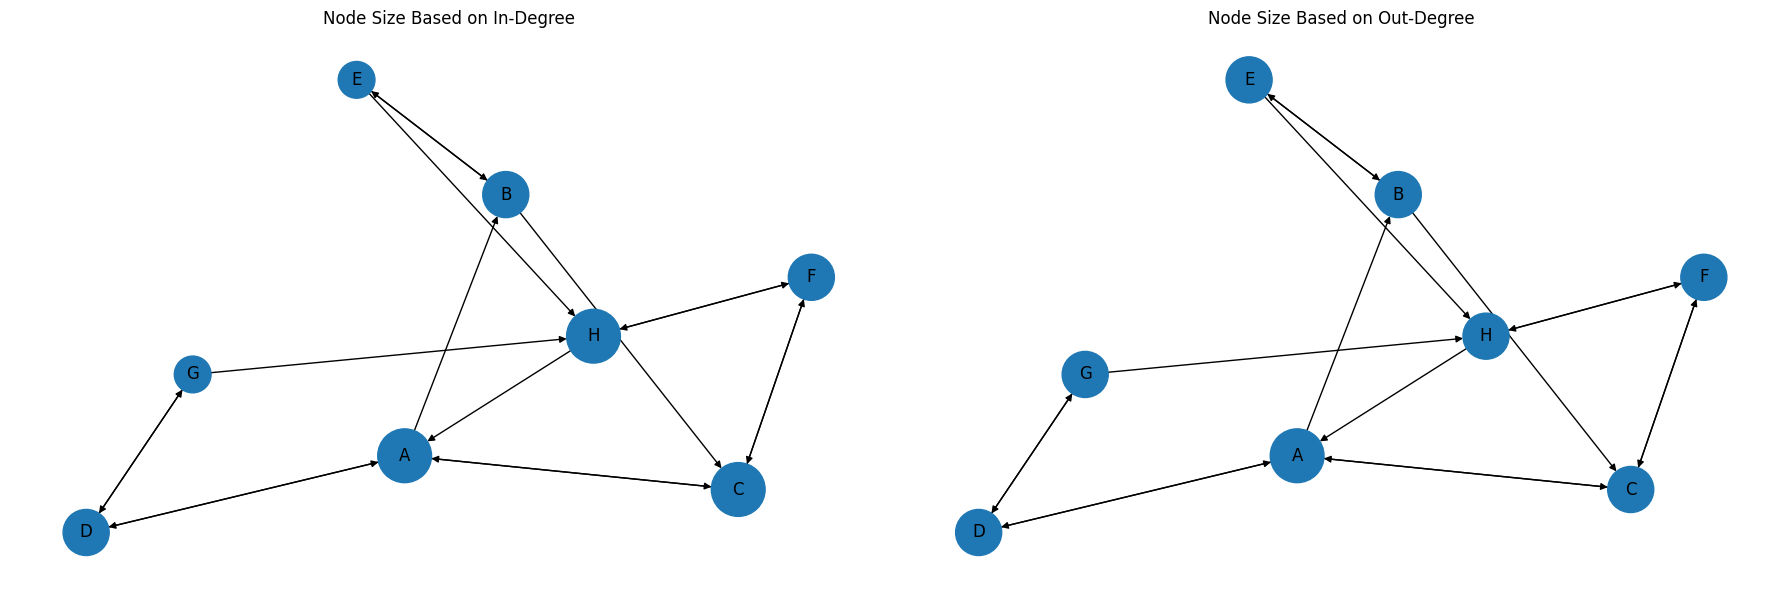

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# ----- Create Directed Graph -----
G = nx.DiGraph()
G.add_edges_from([
    ('A','B'), ('A','C'), ('A','D'),
    ('B','C'), ('B','E'),
    ('C','A'), ('C','F'),
    ('D','A'), ('D','G'),
    ('E','B'), ('E','H'),
    ('F','C'), ('F','H'),
    ('G','D'), ('G','H'),
    ('H','A'), ('H','F')
])

# Layout (same for all plots)
pos = nx.spring_layout(G, seed=7)

# Degree calculations
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
total_deg = dict(G.degree())   # in + out

# Scaling function for node sizes
def scale(deg_dict):
    return [300 + deg_dict[n] * 400 for n in G.nodes()]  # 300 base + scaled

sizes_in = scale(in_deg)
sizes_out = scale(out_deg)
sizes_total = scale(total_deg)

# ----- Plotting 3 Subplots -----
plt.figure(figsize=(18, 6))

# 1. In-Degree Plot
plt.subplot(1, 2, 1)
nx.draw(G, pos, with_labels=True, node_size=sizes_in, arrows=True)
plt.title("Node Size Based on In-Degree")

# 2. Out-Degree Plot
plt.subplot(1, 2, 2)
nx.draw(G, pos, with_labels=True, node_size=sizes_out, arrows=True)
plt.title("Node Size Based on Out-Degree")



plt.tight_layout()
plt.show()


### Q1(B) UNDIRECTED GRAPH BASED ON TOTAL DEGREE

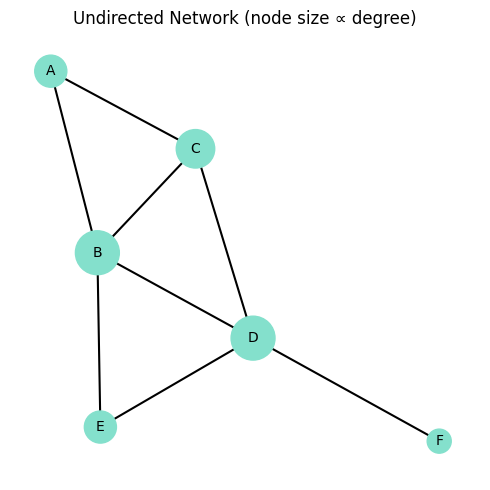

In [3]:
import networkx as nx
import matplotlib.pyplot as plt


G = nx.Graph()
edges = [
    ('A','B'),
    ('A','C'),
    ('B','C'),
    ('C','D'),
    ('D','B'),
    ('B','E'),
    ('F','D'),
    ('E','D'),
]

G.add_edges_from(edges)

# Node Degrees
deg_dict = dict(G.degree())

# Scale node sizes based on degree
min_size, max_size = 300, 1000
sizes = [
    min_size + (max_size - min_size) * (deg_dict[n] - min(deg_dict.values())) /
    (max(deg_dict.values()) - min(deg_dict.values()) + 1e-9)
    for n in G.nodes()
]

# --- Draw Graph ---
pos = nx.spring_layout(G, seed=7)

plt.figure(figsize=(5, 5))

nx.draw_networkx_nodes(G, pos, node_size=sizes,node_color="#84e0cc")
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, width=1.5)

plt.title("Undirected Network (node size ∝ degree)")
plt.axis('off')
plt.tight_layout()
plt.show()


### Q1(C)Plot an unweighted, undirected network such that the node size is proportional to the degree(on real world network)

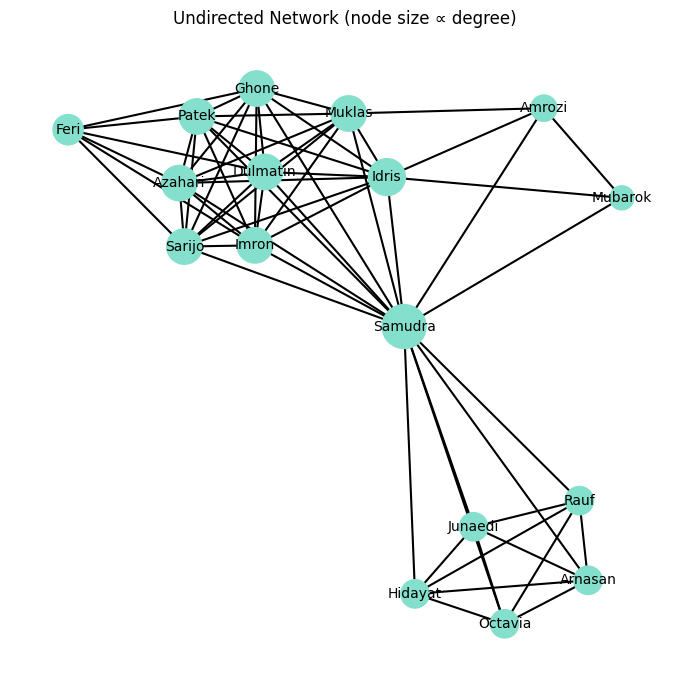

In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/SNA Datasets/Bali.txt', sep='\t', header=None, names=['Source', 'Target', 'Weight'])

G = nx.from_pandas_edgelist(df, source='Source', target='Target', create_using=nx.Graph())

# Node Degrees
deg_dict = dict(G.degree())

# Scale node sizes based on degree
min_size, max_size = 300, 1000
sizes = [
    min_size + (max_size - min_size) * (deg_dict[n] - min(deg_dict.values())) /
    (max(deg_dict.values()) - min(deg_dict.values()) + 1e-9)
    for n in G.nodes()
]

# --- Draw Graph ---
pos = nx.spring_layout(G, seed=7)

plt.figure(figsize=(7, 7))

nx.draw_networkx_nodes(G, pos, node_size=sizes,node_color="#84e0cc")
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, width=1.5)

plt.title("Undirected Network (node size ∝ degree)")
plt.axis('off')
plt.tight_layout()
plt.show()


### Q1(D)Plot a weighted, directed network such that the node size and edge width are proportional to the in-degree and edge weight respectively(on real world network)

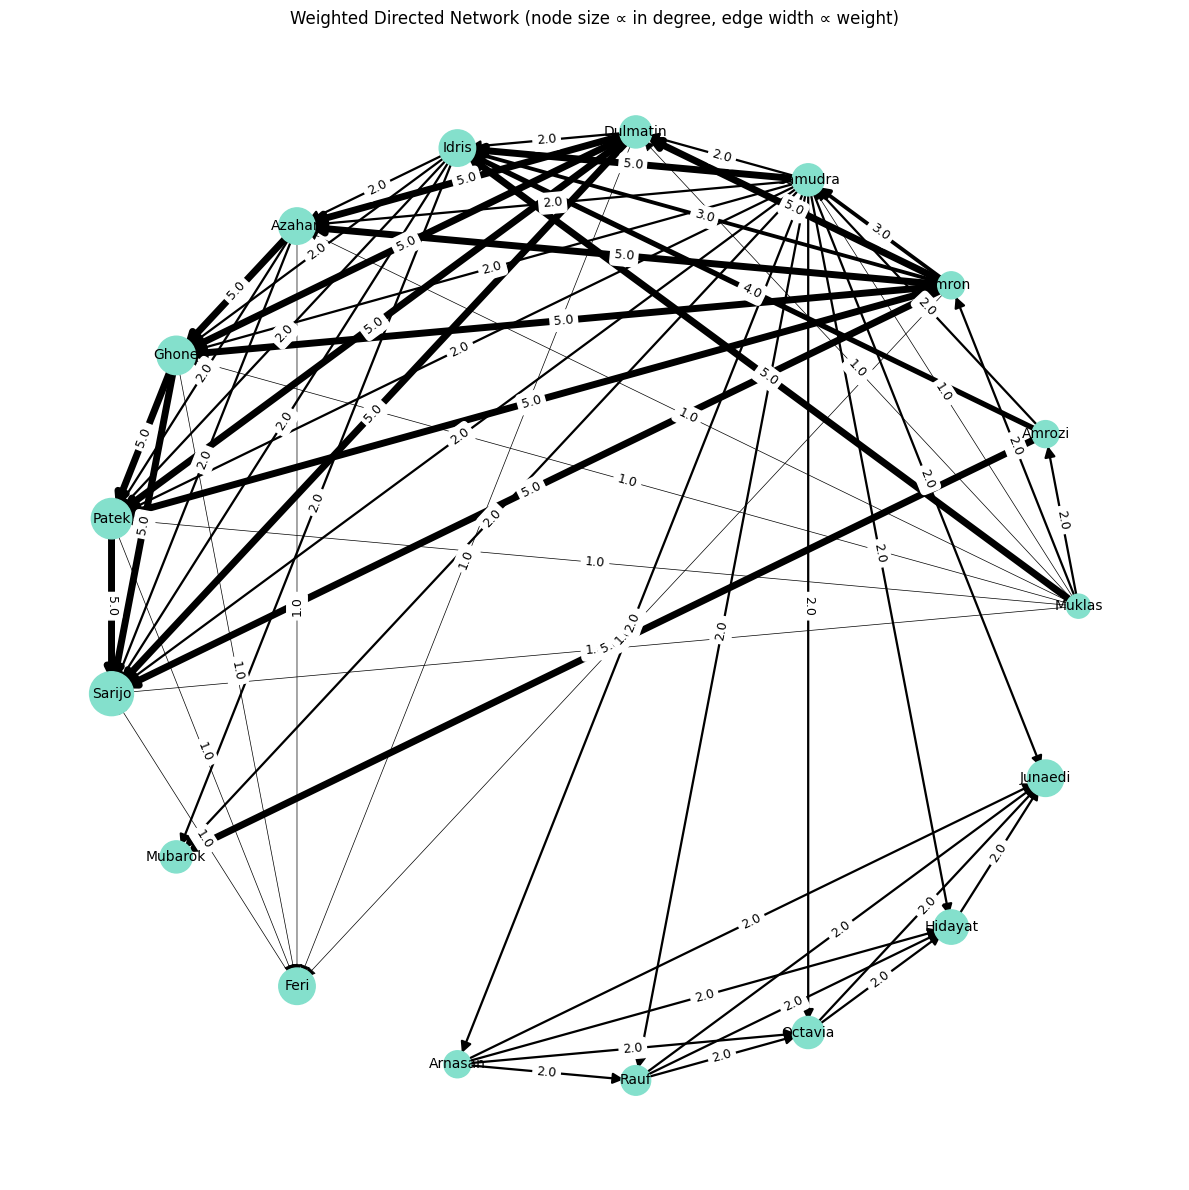

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/SNA Datasets/Bali.txt', sep='\t', header=None, names=['Source', 'Target', 'Weight'])

G = nx.from_pandas_edgelist(df, source='Source', target='Target', edge_attr='Weight', create_using=nx.DiGraph())


# Node Sizes proportional to In Degree
deg_dict = {n: G.in_degree(n) for n in G.nodes()}

# Scaling sizes to scale nodes to
min_size, max_size = 300, 1000
sizes = [
    min_size + (max_size - min_size) * (deg_dict[n] - min(deg_dict.values())) /
    (max(deg_dict.values()) - min(deg_dict.values()) + 1e-9)
    # Min max normalisation
    for n in G.nodes()
]

# Edge Width proportional Edge Weights
weights = nx.get_edge_attributes(G, 'Weight') # Changed 'weight' to 'Weight'
min_w, max_w = min(weights.values()), max(weights.values())
edge_widths = [
    0.5 + 4.5 * (weights[e] - min_w) / (max_w - min_w + 1e-9)
    for e in G.edges()
]

# ----- Layout & draw -----
pos = nx.circular_layout(G)
plt.figure(figsize=(12,12))
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color='#84e0cc')
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, width=edge_widths, arrows=True, arrowstyle='-|>', arrowsize=16)
# Annotate edge weights
nx.draw_networkx_edge_labels(G, pos, edge_labels={e: f"{w:.1f}" for e,w in weights.items()}, font_size=9)

plt.title("Weighted Directed Network (node size ∝ in degree, edge width ∝ weight)")
plt.axis('off')
plt.tight_layout()
plt.show()



### Q2(A) Compute and plot the degree distribution, cumulative degree distributions of four real-world networks(networks with approx 100, 1000, 10,000, 100,000 nodes).Also compute local and global properties of the network.

In [6]:
# User Defined Functions
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations


def degree_centrality_ud(G):
    deg = dict(G.degree())
    maxdeg = max(deg.values()) if deg else 1
    return {v: deg[v] / maxdeg for v in G.nodes()}


def closeness_centrality_ud(G):
    closeness = {}
    for v in G.nodes():

        dist = nx.shortest_path_length(G, source=v)

        total_dist_to_others = sum(d for node, d in dist.items() if node != v)

        reachable_others_count = len(dist) - 1

        if reachable_others_count > 0 and total_dist_to_others > 0:
            closeness[v] = reachable_others_count / total_dist_to_others
        else:
            closeness[v] = 0.0
    return closeness

def betweenness_centrality_ud(G):
    Cb = dict.fromkeys(G.nodes(), 0.0)
    N = len(G.nodes())

    if N <= 2:
        return Cb

    for s, t in combinations(G.nodes(), 2):
        try:

            paths = list(nx.all_shortest_paths(G, source=s, target=t))
            sigma_st = len(paths)

            for path in paths:
                intermediates = path[1:-1]
                for v_int in intermediates:
                    Cb[v_int] += 1 / sigma_st
        except nx.NetworkXNoPath:
            continue

    normalization_factor = 2.0 / ((N - 1) * (N - 2))
    for v in Cb:
        Cb[v] *= normalization_factor
    return Cb

#### 1.Karate club network


=== DEGREE MEASURES ===
Node 0: Degree=16
Node 1: Degree=9
Node 2: Degree=10
Node 3: Degree=6
Node 4: Degree=3
Node 5: Degree=4
Node 6: Degree=4
Node 7: Degree=4
Node 8: Degree=5
Node 9: Degree=2
Node 10: Degree=3
Node 11: Degree=1
Node 12: Degree=2
Node 13: Degree=5
Node 14: Degree=2
Node 15: Degree=2
Node 16: Degree=2
Node 17: Degree=2
Node 18: Degree=2
Node 19: Degree=3
Node 20: Degree=2
Node 21: Degree=2
Node 22: Degree=2
Node 23: Degree=5
Node 24: Degree=3
Node 25: Degree=3
Node 26: Degree=2
Node 27: Degree=4
Node 28: Degree=3
Node 29: Degree=4
Node 30: Degree=4
Node 31: Degree=6
Node 32: Degree=12
Node 33: Degree=17
Degree (k) : P(k)
1 : 0.0294
2 : 0.3235
3 : 0.1765
4 : 0.1765
5 : 0.0882
6 : 0.0588
9 : 0.0294
10 : 0.0294
12 : 0.0294
16 : 0.0294
17 : 0.0294


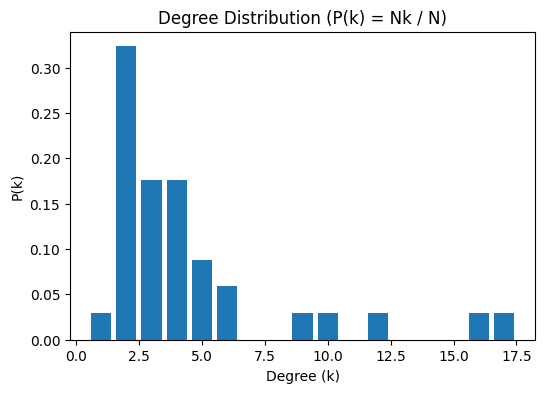

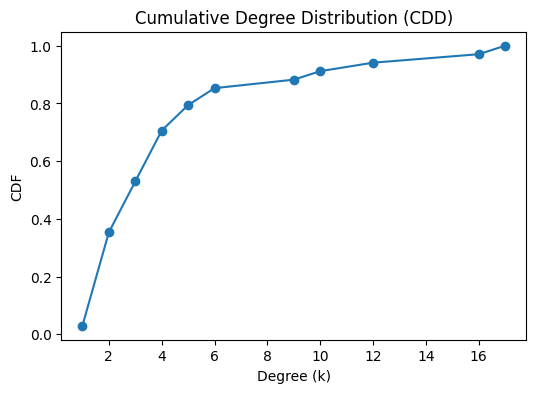

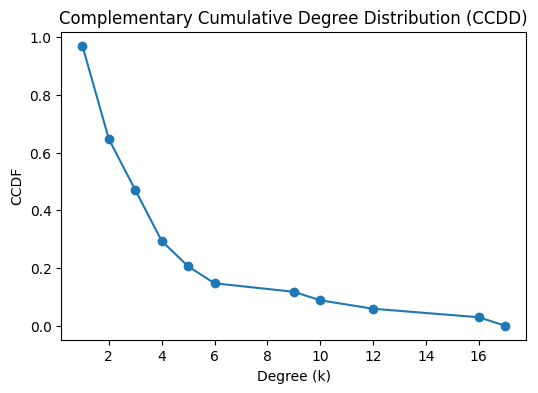


=== CLUSTERING ===
Local Clustering Coefficients: {0: 0.15, 1: 0.3333333333333333, 2: 0.24444444444444444, 3: 0.6666666666666666, 4: 0.6666666666666666, 5: 0.5, 6: 0.5, 7: 1.0, 8: 0.5, 9: 0, 10: 0.6666666666666666, 11: 0, 12: 1.0, 13: 0.6, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0, 19: 0.3333333333333333, 20: 1.0, 21: 1.0, 22: 1.0, 23: 0.4, 24: 0.3333333333333333, 25: 0.3333333333333333, 26: 1.0, 27: 0.16666666666666666, 28: 0.3333333333333333, 29: 0.6666666666666666, 30: 0.5, 31: 0.2, 32: 0.19696969696969696, 33: 0.11029411764705882}
Global Clustering Coefficient: 0.5706

=== USER-DEFINED CENTRALITY MEASURES ===
Node 0: DegreeC=0.941, ClosenessC=0.569, BetweennessC=0.438
Node 1: DegreeC=0.529, ClosenessC=0.485, BetweennessC=0.054
Node 2: DegreeC=0.588, ClosenessC=0.559, BetweennessC=0.144
Node 3: DegreeC=0.353, ClosenessC=0.465, BetweennessC=0.012
Node 4: DegreeC=0.176, ClosenessC=0.379, BetweennessC=0.001
Node 5: DegreeC=0.235, ClosenessC=0.384, BetweennessC=0.030
Node 6: DegreeC=

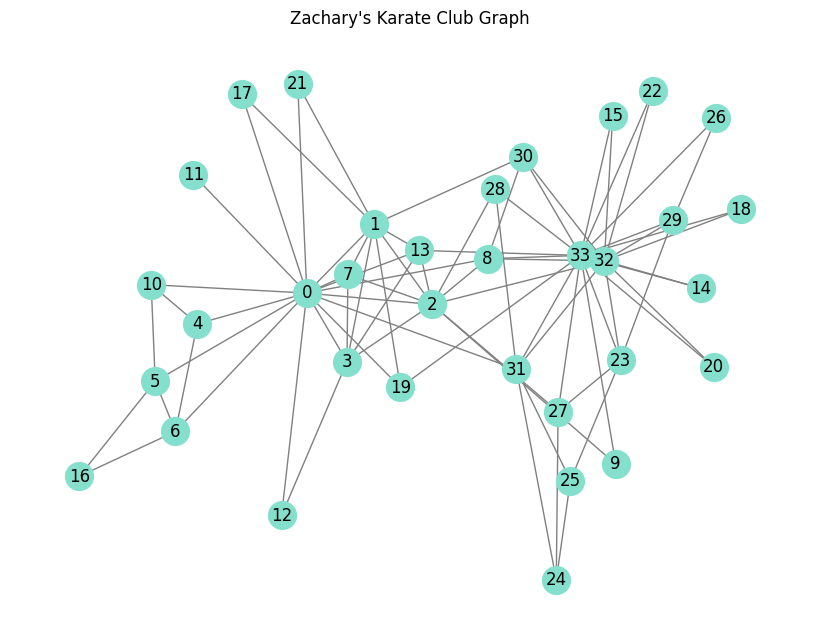

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.karate_club_graph()



# Degree Measures

total_deg = G.degree()


print("\n=== DEGREE MEASURES ===")
for n in G.nodes():
    print(f"Node {n}: Degree={total_deg[n]}")

# Degree Distribution
degrees = [deg for _, deg in G.degree()]
unique_k, Nk = np.unique(degrees, return_counts=True)
N = G.number_of_nodes()

# Step 3: Compute P(k) = Nk / N
Pk = Nk / N

print("Degree (k) : P(k)")
for k, p in zip(unique_k, Pk):
    print(f"{k} : {p:.4f}")

plt.figure(figsize=(6,4))
plt.bar(unique_k, Pk)
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.title("Degree Distribution (P(k) = Nk / N)")
plt.show()


# Cumulative Degree Distribution (CDD)
cdf = np.cumsum(Pk)  # cumulative sum of P(k)
plt.figure(figsize=(6,4))
plt.plot(unique_k, cdf, marker='o')
plt.xlabel("Degree (k)")
plt.ylabel("CDF")
plt.title("Cumulative Degree Distribution (CDD)")
plt.show()

# Complementary CDF (CCDD)
ccdf = 1 - cdf
plt.figure(figsize=(6,4))
plt.plot(unique_k, ccdf, marker='o')
plt.xlabel("Degree (k)")
plt.ylabel("CCDF")
plt.title("Complementary Cumulative Degree Distribution (CCDD)")
plt.show()


#Clustering
LCC = nx.clustering(G.to_undirected())  # local clustering coefficient per node
GCC = nx.average_clustering(G.to_undirected())  # global clustering coefficient

print("\n=== CLUSTERING ===")
print("Local Clustering Coefficients:", LCC)
print("Global Clustering Coefficient:", round(GCC, 4))


# Compute Centralities

GU = G.to_undirected()
DC = degree_centrality_ud(G)
CC = closeness_centrality_ud(GU)
BC = betweenness_centrality_ud(GU)


print("\n=== USER-DEFINED CENTRALITY MEASURES ===")
for v in G.nodes():
    print(f"Node {v}: DegreeC={DC[v]:.3f}, ClosenessC={CC[v]:.3f}, BetweennessC={BC[v]:.3f}")
pos = nx.spring_layout(G, seed=7)

plt.figure(figsize=(8, 6))

# Draw graph
nx.draw(
    G, pos,
    with_labels=True,
    node_color='#84e0cc',
    node_size=400,
    edge_color='gray'
)

plt.title("Zachary's Karate Club Graph")
plt.show()



#### 2.PoliticalBooks


=== DEGREE MEASURES ===
Node 1: Degree=6
Node 2: Degree=4
Node 3: Degree=4
Node 4: Degree=23
Node 5: Degree=8
Node 6: Degree=7
Node 7: Degree=11
Node 8: Degree=8
Node 9: Degree=25
Node 10: Degree=16
Node 11: Degree=15
Node 12: Degree=18
Node 13: Degree=25
Node 14: Degree=13
Node 15: Degree=9
Node 16: Degree=5
Node 17: Degree=3
Node 18: Degree=5
Node 19: Degree=3
Node 20: Degree=5
Node 21: Degree=10
Node 22: Degree=5
Node 23: Degree=7
Node 24: Degree=9
Node 25: Degree=9
Node 26: Degree=5
Node 27: Degree=9
Node 28: Degree=9
Node 29: Degree=3
Node 30: Degree=4
Node 31: Degree=20
Node 32: Degree=11
Node 33: Degree=13
Node 34: Degree=15
Node 35: Degree=5
Node 36: Degree=5
Node 37: Degree=9
Node 38: Degree=10
Node 39: Degree=7
Node 40: Degree=18
Node 41: Degree=8
Node 42: Degree=6
Node 43: Degree=5
Node 44: Degree=5
Node 45: Degree=6
Node 46: Degree=4
Node 47: Degree=18
Node 48: Degree=4
Node 49: Degree=8
Node 50: Degree=3
Node 51: Degree=6
Node 52: Degree=5
Node 53: Degree=7
Node 54: Degre

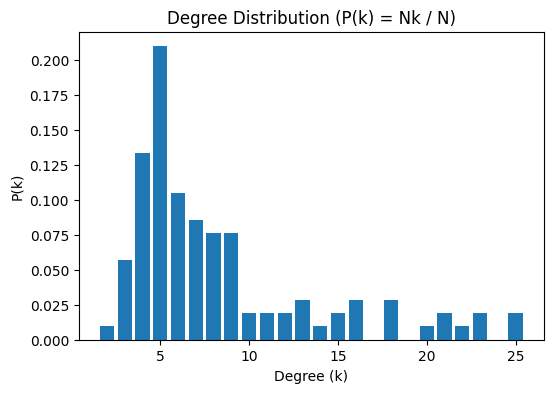

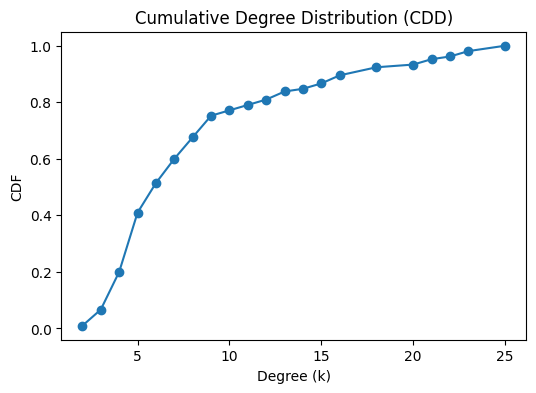

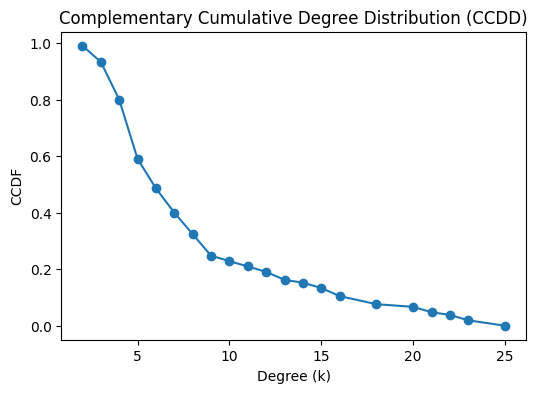


=== CLUSTERING ===
Local Clustering Coefficients: {1: 0.6, 2: 0.8333333333333334, 3: 0.6666666666666666, 4: 0.20948616600790515, 5: 0.25, 6: 0.5238095238095238, 7: 0.18181818181818182, 8: 0.17857142857142858, 9: 0.25333333333333335, 10: 0.3, 11: 0.3047619047619048, 12: 0.29411764705882354, 13: 0.23333333333333334, 14: 0.3333333333333333, 15: 0.4166666666666667, 16: 0.7, 17: 1.0, 18: 0.9, 19: 0.6666666666666666, 20: 0.2, 21: 0.4, 22: 0.8, 23: 0.3333333333333333, 24: 0.5, 25: 0.6111111111111112, 26: 0.4, 27: 0.5277777777777778, 28: 0.5833333333333334, 29: 0.3333333333333333, 30: 0.3333333333333333, 31: 0.26842105263157895, 32: 0.4, 33: 0.19230769230769232, 34: 0.2571428571428571, 35: 0.3, 36: 0.8, 37: 0.5277777777777778, 38: 0.35555555555555557, 39: 0.5238095238095238, 40: 0.27450980392156865, 41: 0.6428571428571429, 42: 0.5333333333333333, 43: 0.4, 44: 0.8, 45: 0.7333333333333333, 46: 0.3333333333333333, 47: 0.27450980392156865, 48: 0.8333333333333334, 49: 0.25, 50: 0.3333333333333333,

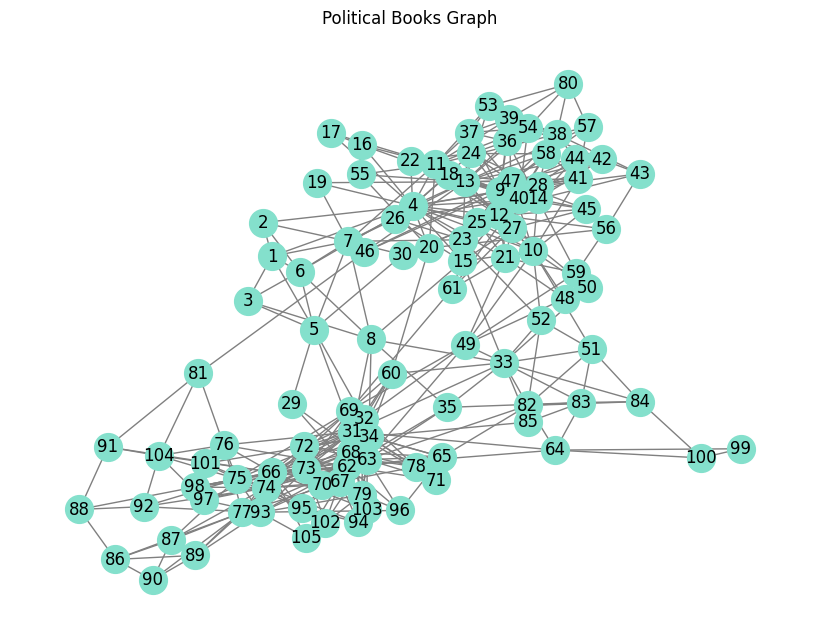

In [8]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/SNA Datasets/PoliticalBooks.txt', sep='\t', names=['Source', 'Target'], header=0)
G = nx.from_pandas_edgelist(df, source='Source', target='Target', create_using=nx.Graph())

total_deg = G.degree()


print("\n=== DEGREE MEASURES ===")
for n in G.nodes():
    print(f"Node {n}: Degree={total_deg[n]}")

# Degree Distribution
degrees = [deg for _, deg in G.degree()]
unique_k, Nk = np.unique(degrees, return_counts=True)
N = G.number_of_nodes()

# Step 3: Compute P(k) = Nk / N
Pk = Nk / N

print("Degree (k) : P(k)")
for k, p in zip(unique_k, Pk):
    print(f"{k} : {p:.4f}")

plt.figure(figsize=(6,4))
plt.bar(unique_k, Pk)
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.title("Degree Distribution (P(k) = Nk / N)")
plt.show()


# Cumulative Degree Distribution (CDD)
cdf = np.cumsum(Pk)  # cumulative sum of P(k)
plt.figure(figsize=(6,4))
plt.plot(unique_k, cdf, marker='o')
plt.xlabel("Degree (k)")
plt.ylabel("CDF")
plt.title("Cumulative Degree Distribution (CDD)")
plt.show()

# Complementary CDF (CCDD)
ccdf = 1 - cdf
plt.figure(figsize=(6,4))
plt.plot(unique_k, ccdf, marker='o')
plt.xlabel("Degree (k)")
plt.ylabel("CCDF")
plt.title("Complementary Cumulative Degree Distribution (CCDD)")
plt.show()


#Clustering
LCC = nx.clustering(G.to_undirected())  # local clustering coefficient per node
GCC = nx.average_clustering(G.to_undirected())  # global clustering coefficient

print("\n=== CLUSTERING ===")
print("Local Clustering Coefficients:", LCC)
print("Global Clustering Coefficient:", round(GCC, 4))


# Compute Centralities

GU = G.to_undirected()
DC = degree_centrality_ud(G)
CC = closeness_centrality_ud(GU)
BC = betweenness_centrality_ud(GU)


print("\n=== USER-DEFINED CENTRALITY MEASURES ===")
for v in G.nodes():
    print(f"Node {v}: DegreeC={DC[v]:.3f}, ClosenessC={CC[v]:.3f}, BetweennessC={BC[v]:.3f}")
pos = nx.spring_layout(G, seed=7)

plt.figure(figsize=(8, 6))

# Draw graph
nx.draw(
    G, pos,
    with_labels=True,
    node_color='#84e0cc',
    node_size=400,
    edge_color='gray'
)

plt.title("Political Books Graph")
plt.show()



#### 3.Hamsterster dataset


=== DEGREE MEASURES ===
Node 1: Degree=18
Node 2: Degree=87
Node 3: Degree=83
Node 4: Degree=72
Node 5: Degree=101
Node 6: Degree=151
Node 7: Degree=43
Node 8: Degree=6
Node 11: Degree=88
Node 1308: Degree=16
Node 1542: Degree=47
Node 1829: Degree=35
Node 1863: Degree=9
Node 2070: Degree=21
Node 2076: Degree=7
Node 2077: Degree=15
Node 2078: Degree=6
Node 2079: Degree=22
Node 2373: Degree=13
Node 13: Degree=87
Node 18: Degree=54
Node 19: Degree=68
Node 20: Degree=91
Node 21: Degree=104
Node 23: Degree=27
Node 46: Degree=24
Node 50: Degree=22
Node 69: Degree=148
Node 93: Degree=43
Node 94: Degree=44
Node 95: Degree=50
Node 96: Degree=51
Node 118: Degree=50
Node 119: Degree=62
Node 159: Degree=74
Node 160: Degree=31
Node 161: Degree=32
Node 165: Degree=32
Node 166: Degree=26
Node 167: Degree=57
Node 198: Degree=24
Node 204: Degree=33
Node 207: Degree=34
Node 224: Degree=53
Node 235: Degree=35
Node 236: Degree=38
Node 413: Degree=22
Node 414: Degree=22
Node 417: Degree=21
Node 418: Degre

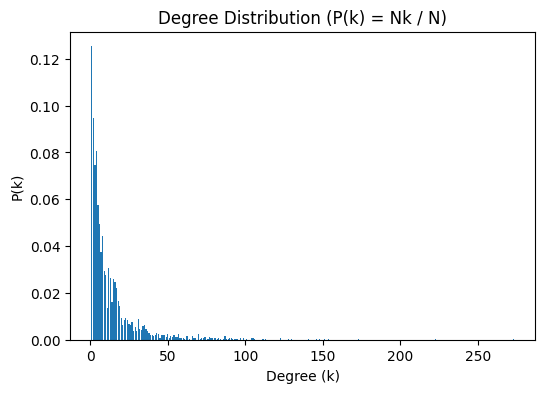

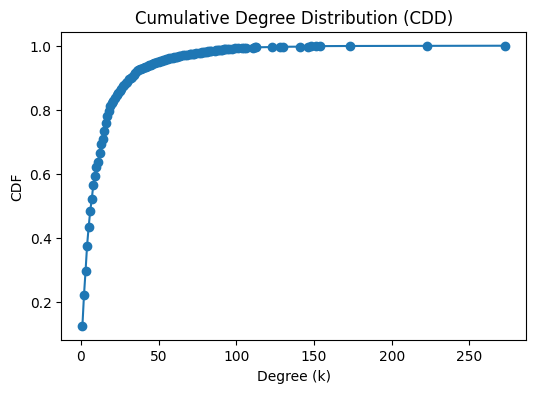

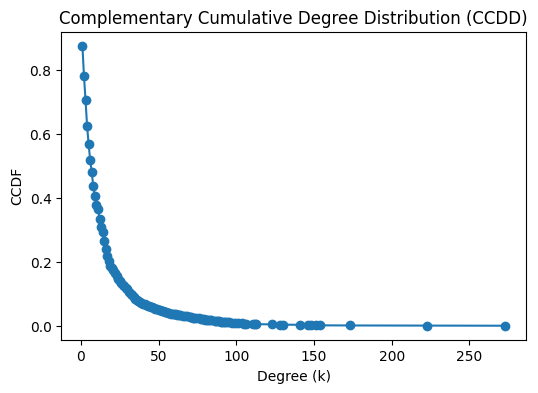


=== CLUSTERING ===
Local Clustering Coefficients: {1: 0.3660130718954248, 2: 0.09248863940122962, 3: 0.0946223920070526, 4: 0.12363067292644757, 5: 0.09405940594059406, 6: 0.051125827814569536, 7: 0.14839424141749724, 8: 0, 11: 0.06844305120167189, 1308: 0.4, 1542: 0.44680851063829785, 1829: 0.2504201680672269, 1863: 0.4722222222222222, 2070: 0.49523809523809526, 2076: 0.8571428571428571, 2077: 0.5714285714285714, 2078: 0.9333333333333333, 2079: 0.41125541125541126, 2373: 0.7051282051282052, 13: 0.057203956161454156, 18: 0.16701607267645002, 19: 0.12818261633011413, 20: 0.08522588522588523, 21: 0.07766990291262135, 23: 0.13675213675213677, 46: 0.21739130434782608, 50: 0.21212121212121213, 69: 0.07777164920022063, 93: 0.2425249169435216, 94: 0.23995771670190275, 95: 0.24, 96: 0.23215686274509803, 118: 0.12081632653061225, 119: 0.09836065573770492, 159: 0.11477230655312846, 160: 0.15483870967741936, 161: 0.2762096774193548, 165: 0.25, 166: 0.16615384615384615, 167: 0.15225563909774437, 

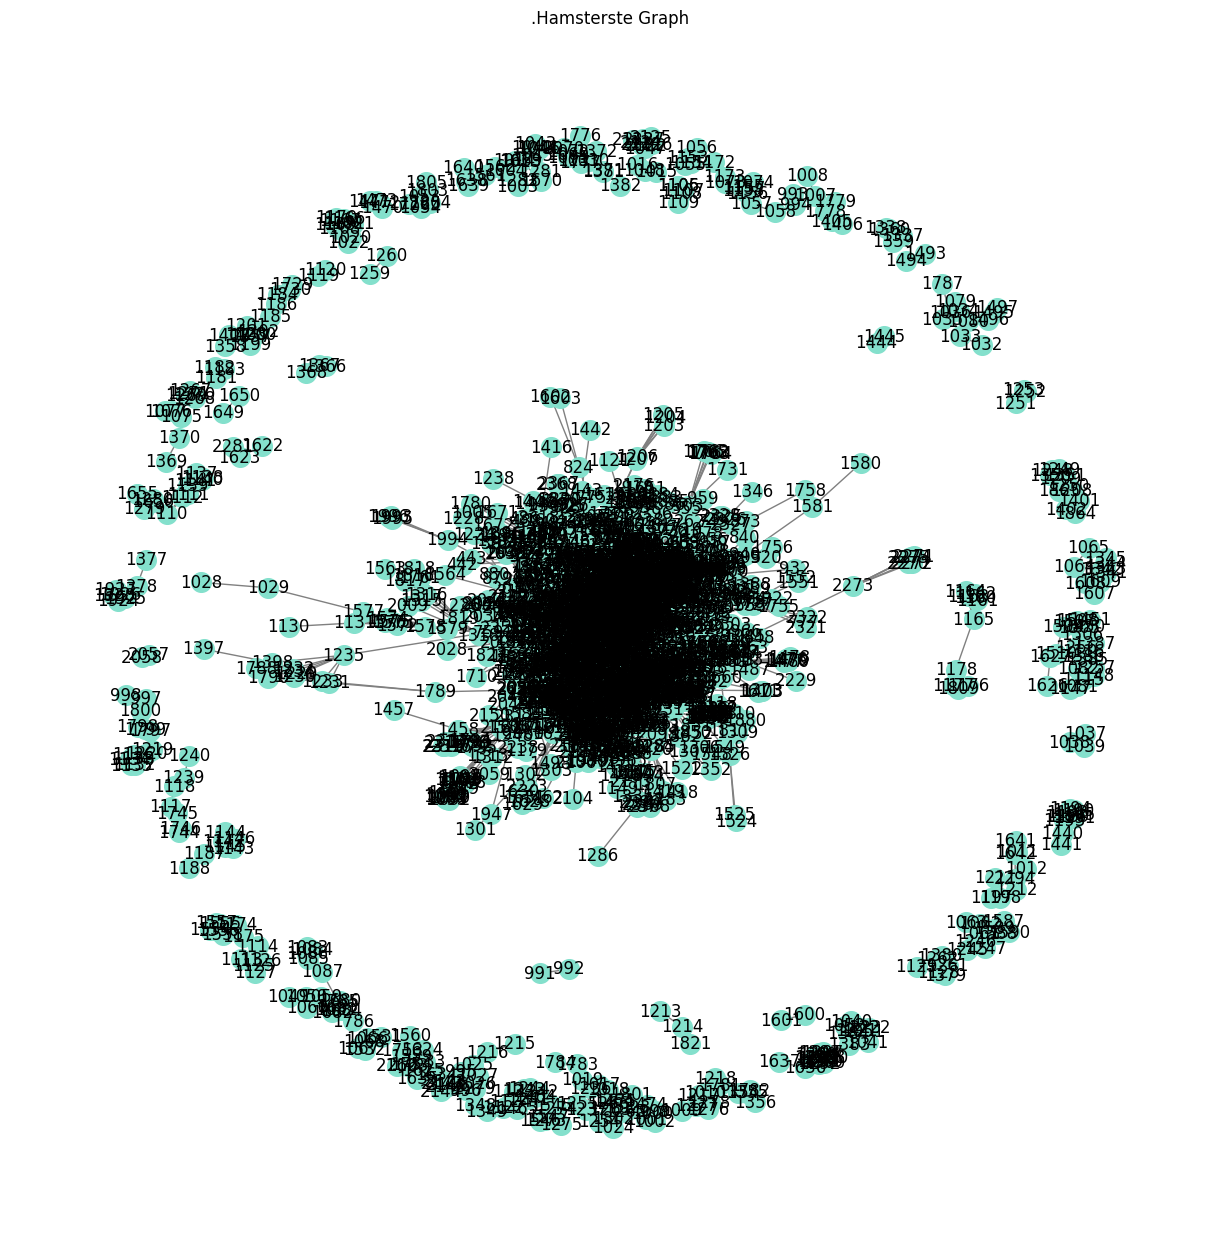

In [9]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/SNA Datasets/soc-hamsterster.edges', sep=' ', names=['Source', 'Target'], header=None)
G = nx.from_pandas_edgelist(df, source='Source', target='Target', create_using=nx.Graph())

total_deg = G.degree()


print("\n=== DEGREE MEASURES ===")
for n in G.nodes():
    print(f"Node {n}: Degree={total_deg[n]}")

# Degree Distribution
degrees = [deg for _, deg in G.degree()]
unique_k, Nk = np.unique(degrees, return_counts=True)
N = G.number_of_nodes()

# Step 3: Compute P(k) = Nk / N
Pk = Nk / N

print("Degree (k) : P(k)")
for k, p in zip(unique_k, Pk):
    print(f"{k} : {p:.4f}")

plt.figure(figsize=(6,4))
plt.bar(unique_k, Pk)
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.title("Degree Distribution (P(k) = Nk / N)")
plt.show()


# Cumulative Degree Distribution (CDD)
cdf = np.cumsum(Pk)  # cumulative sum of P(k)
plt.figure(figsize=(6,4))
plt.plot(unique_k, cdf, marker='o')
plt.xlabel("Degree (k)")
plt.ylabel("CDF")
plt.title("Cumulative Degree Distribution (CDD)")
plt.show()

# Complementary CDF (CCDD)
ccdf = 1 - cdf
plt.figure(figsize=(6,4))
plt.plot(unique_k, ccdf, marker='o')
plt.xlabel("Degree (k)")
plt.ylabel("CCDF")
plt.title("Complementary Cumulative Degree Distribution (CCDD)")
plt.show()


#Clustering
LCC = nx.clustering(G.to_undirected())  # local clustering coefficient per node
GCC = nx.average_clustering(G.to_undirected())  # global clustering coefficient

print("\n=== CLUSTERING ===")
print("Local Clustering Coefficients:", LCC)
print("Global Clustering Coefficient:", round(GCC, 4))


# Compute Centralities Scipped due to long Computation times

# GU = G.to_undirected()
# DC = degree_centrality_ud(G)
# CC = closeness_centrality_ud(GU)
# BC = betweenness_centrality_ud(GU)


# print("\n=== USER-DEFINED CENTRALITY MEASURES ===")
# for v in G.nodes():
#   print(f"Node {v}: DegreeC={DC[v]:.3f}, ClosenessC={CC[v]:.3f}, BetweennessC={BC[v]:.3f}")


pos = nx.spring_layout(G, seed=7)

plt.figure(figsize=(12, 12))

# Draw graph
nx.draw(
    G, pos,
    with_labels=True,
    node_color='#84e0cc',
    node_size=200,
    edge_color='gray'
)

plt.title(".Hamsterste Graph")
plt.show()


#### 4.Euroroad


=== DEGREE MEASURES ===
Node 1: Degree=1
Node 2: Degree=3
Node 3: Degree=2
Node 17: Degree=3
Node 4: Degree=3
Node 5: Degree=1
Node 855: Degree=2
Node 6: Degree=2
Node 7: Degree=8
Node 880: Degree=2
Node 8: Degree=5
Node 22: Degree=3
Node 23: Degree=6
Node 411: Degree=5
Node 453: Degree=5
Node 454: Degree=5
Node 889: Degree=2
Node 9: Degree=5
Node 479: Degree=4
Node 480: Degree=2
Node 561: Degree=5
Node 10: Degree=4
Node 537: Degree=4
Node 1074: Degree=3
Node 11: Degree=3
Node 536: Degree=3
Node 12: Degree=5
Node 560: Degree=2
Node 13: Degree=4
Node 27: Degree=4
Node 30: Degree=3
Node 559: Degree=4
Node 14: Degree=2
Node 596: Degree=2
Node 1138: Degree=2
Node 34: Degree=3
Node 15: Degree=1
Node 16: Degree=2
Node 18: Degree=3
Node 19: Degree=5
Node 823: Degree=2
Node 20: Degree=2
Node 388: Degree=2
Node 389: Degree=3
Node 627: Degree=2
Node 21: Degree=1
Node 409: Degree=4
Node 885: Degree=4
Node 24: Degree=3
Node 538: Degree=4
Node 1078: Degree=1
Node 1109: Degree=2
Node 25: Degree=2
N

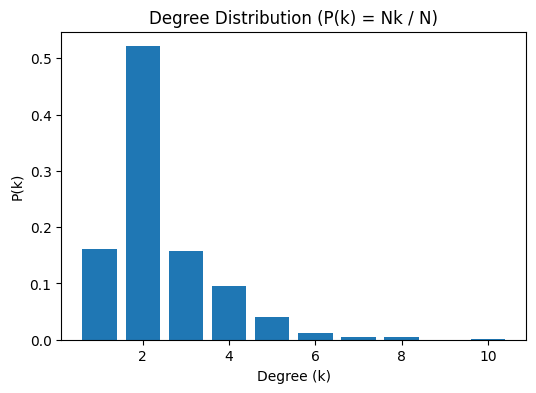

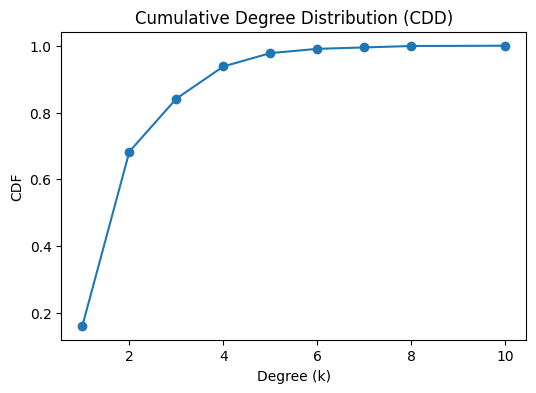

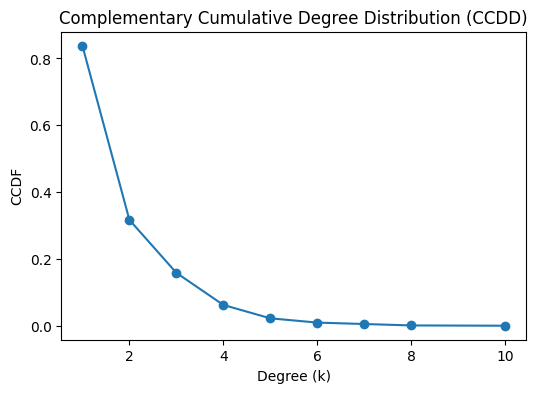


=== CLUSTERING ===
Local Clustering Coefficients: {1: 0, 2: 0, 3: 0, 17: 0, 4: 0, 5: 0, 855: 0, 6: 0, 7: 0, 880: 0, 8: 0.1, 22: 0, 23: 0, 411: 0, 453: 0.1, 454: 0, 889: 0, 9: 0.2, 479: 0.16666666666666666, 480: 0, 561: 0.2, 10: 0.16666666666666666, 537: 0, 1074: 0, 11: 0, 536: 0, 12: 0, 560: 0, 13: 0, 27: 0, 30: 0, 559: 0, 14: 0, 596: 0, 1138: 0, 34: 0, 15: 0, 16: 0, 18: 0, 19: 0, 823: 0, 20: 0, 388: 0, 389: 0, 627: 0, 21: 0, 409: 0, 885: 0, 24: 0, 538: 0, 1078: 0, 1109: 0, 25: 0, 1110: 0, 26: 0, 28: 0, 29: 0, 31: 0, 32: 0, 33: 0, 1159: 0, 35: 0, 36: 0, 392: 0, 37: 0, 631: 0, 38: 0, 628: 0, 863: 0, 1011: 0, 39: 0.03571428571428571, 40: 0, 412: 0, 413: 0.16666666666666666, 875: 0, 876: 0.16666666666666666, 881: 0, 41: 0, 42: 0, 43: 0.047619047619047616, 882: 0, 44: 0, 50: 0.3333333333333333, 51: 0.1, 455: 0, 45: 0, 46: 0, 888: 0, 47: 0, 485: 0, 1036: 0, 48: 0, 73: 0, 486: 0, 890: 0, 49: 0.16666666666666666, 74: 0, 629: 0.16666666666666666, 52: 0, 901: 0, 53: 0, 54: 0, 55: 0, 540: 0, 56

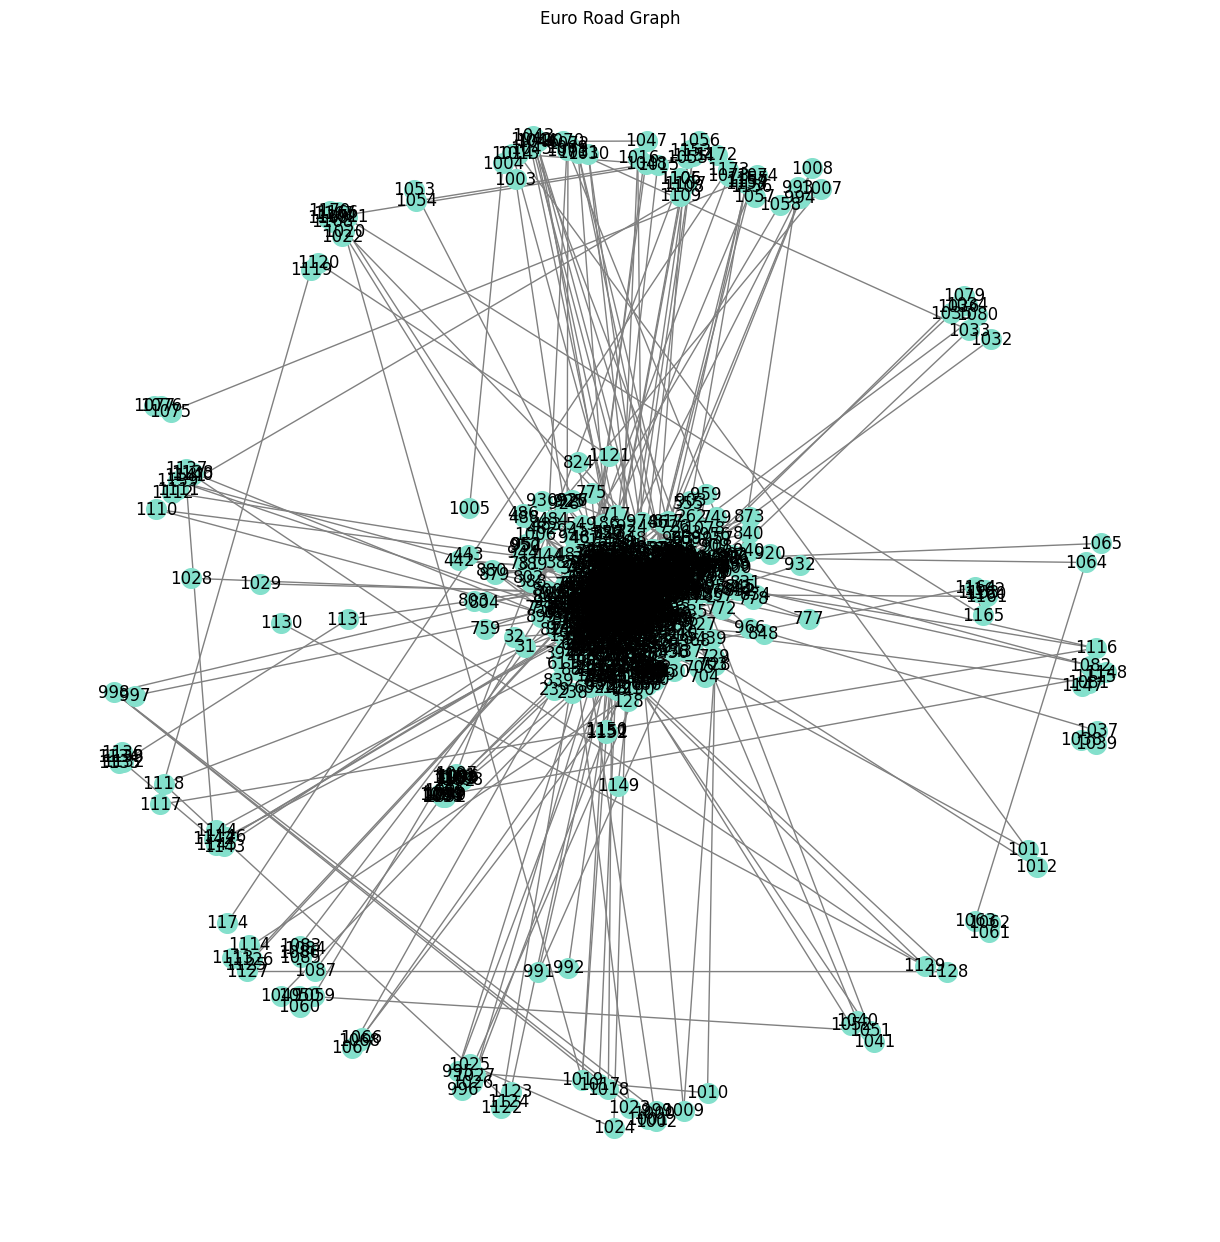

In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/SNA Datasets/road-euroroad.edges', sep=' ', names=['Source', 'Target'], header=None)
G = nx.from_pandas_edgelist(df, source='Source', target='Target', create_using=nx.Graph())

total_deg = G.degree()


print("\n=== DEGREE MEASURES ===")
for n in G.nodes():
    print(f"Node {n}: Degree={total_deg[n]}")

# Degree Distribution
degrees = [deg for _, deg in G.degree()]
unique_k, Nk = np.unique(degrees, return_counts=True)
N = G.number_of_nodes()

# Step 3: Compute P(k) = Nk / N
Pk = Nk / N

print("Degree (k) : P(k)")
for k, p in zip(unique_k, Pk):
    print(f"{k} : {p:.4f}")

plt.figure(figsize=(6,4))
plt.bar(unique_k, Pk)
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.title("Degree Distribution (P(k) = Nk / N)")
plt.show()


# Cumulative Degree Distribution (CDD)
cdf = np.cumsum(Pk)  # cumulative sum of P(k)
plt.figure(figsize=(6,4))
plt.plot(unique_k, cdf, marker='o')
plt.xlabel("Degree (k)")
plt.ylabel("CDF")
plt.title("Cumulative Degree Distribution (CDD)")
plt.show()

# Complementary CDF (CCDD)
ccdf = 1 - cdf
plt.figure(figsize=(6,4))
plt.plot(unique_k, ccdf, marker='o')
plt.xlabel("Degree (k)")
plt.ylabel("CCDF")
plt.title("Complementary Cumulative Degree Distribution (CCDD)")
plt.show()


#Clustering
LCC = nx.clustering(G.to_undirected())  # local clustering coefficient per node
GCC = nx.average_clustering(G.to_undirected())  # global clustering coefficient

print("\n=== CLUSTERING ===")
print("Local Clustering Coefficients:", LCC)
print("Global Clustering Coefficient:", round(GCC, 4))


plt.figure(figsize=(12, 12))

# Draw graph
nx.draw(
    G, pos,
    with_labels=True,
    node_color='#84e0cc',
    node_size=200,
    edge_color='gray'
)

plt.title("Euro Road Graph")
plt.show()


### Q2(B) Implement page rank algorithm and calculate the number of iteration to determine the convergence point and indicate your result with a pre defined page rank function.

In [11]:
import numpy as np
import networkx as nx
import pandas as pd

G = nx.DiGraph()
G.add_edges_from([
    ('A','B'), ('A','C'), ('A','D'),
    ('B','C'), ('B','E'),
    ('C','A'), ('C','F'),
    ('D','A'), ('D','G'),
    ('E','B'), ('E','H'),
    ('F','C'), ('F','H'),
    ('G','D'), ('G','H'),
    ('H','A'), ('H','F')
])

nodes = list(G.nodes())
N = len(nodes)
damping = 0.85
epsilon = 1e-6
max_iterations = 1000

M = np.zeros((N, N))

for i, u in enumerate(nodes):
    out_links = list(G.out_edges(u))
    if len(out_links) > 0:
        prob = 1 / len(out_links)
        for (_, v) in out_links:
            j = nodes.index(v)
            M[j][i] = prob
    else:
        M[:, i] = 1 / N

PR = np.ones(N) / N

for iteration in range(1, max_iterations + 1):
    new_PR = (1 - damping) / N + damping * (M @ PR)
    if np.linalg.norm(new_PR - PR, ord=1) < epsilon:
        print(f"Converged after {iteration} iterations")
        PR = new_PR
        break
    PR = new_PR
else:
    print("Did not converge within iteration limit")

custom_pr = {nodes[i]: PR[i] for i in range(N)}
nx_pr = nx.pagerank(G, alpha=damping)

df = pd.DataFrame({
    "Node": nodes,
    "Custom_PageRank": [custom_pr[n] for n in nodes],
    "NetworkX_PageRank": [nx_pr[n] for n in nodes]
})

df["Difference"] = df["Custom_PageRank"] - df["NetworkX_PageRank"]

df


Converged after 43 iterations


,Node,Custom_PageRank,NetworkX_PageRank,Difference
0,A,0.198145,0.198146,-6.520428e-07
1,B,0.101126,0.101125,3.654201e-07
2,C,0.183815,0.183815,2.920383e-07
3,D,0.101126,0.101125,3.654201e-07
4,E,0.061728,0.061729,-2.078251e-07
5,F,0.155167,0.155167,-4.442176e-07
6,G,0.061728,0.061729,-2.078251e-07
7,H,0.137165,0.137165,4.890321e-07


### Q3 Generate three networks of 1000 nodes each using Random Network Model, Small World Network Model, Preferential Attachment Model and compare their characteristics.

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def Characteristics(G):
  print(f"Number of nodes: {G.number_of_nodes()}")
  print(f"Number of edges: {G.number_of_edges()}")
  print(f"Average clustering coefficient: {nx.average_clustering(G)}")

  degree_sequence = sorted((d for n,d in G.degree), reverse=True)
  print(f"Degree distribution (first 10): {degree_sequence[:10]}")


  components = list(nx.connected_components(G))
  giant_component  = max(components, key=len)
  G_giantcomponent = G.subgraph(giant_component)
  print(f"Average shortest path length: {nx.average_shortest_path_length(G_giantcomponent)}")

#### Random Network Model (Erdos-Renyi)

Properties of Random Network Model (Erdos-Renyi)
Number of nodes: 1000
Number of edges: 1459
Average clustering coefficient: 0.0008285714285714286
Degree distribution (first 10): [12, 11, 10, 10, 9, 9, 8, 8, 8, 8]
Average shortest path length: 6.4194502979629755


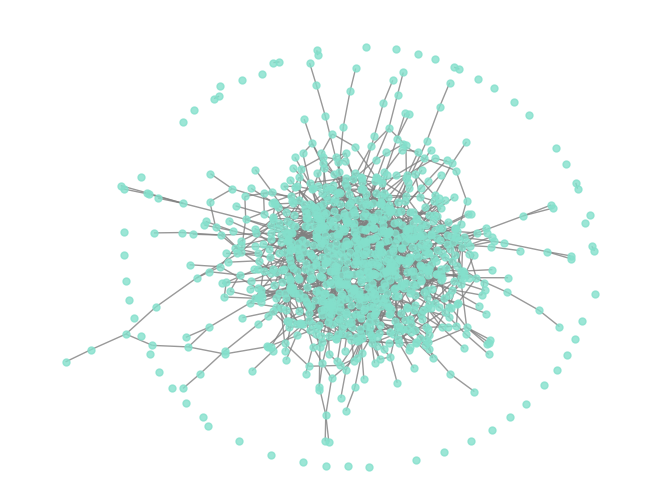

In [13]:
n_ern = 1000
p_ern = 0.003   #(probability of edge creation)
G_ern = nx.erdos_renyi_graph(n_ern, p_ern)

print("Properties of Random Network Model (Erdos-Renyi)")
Characteristics(G_ern)

nx.draw(G_ern, node_size=25, alpha=0.8, node_color="#84e0cc", edge_color="gray")
plt.show()

#### Small World Network Model (Watts-Strogatz)

Properties of Small World Network Model (Watts-Strogatz)
Number of nodes: 1000
Number of edges: 5000
Average clustering coefficient: 0.48822378177378173
Degree distribution (first 10): [14, 13, 13, 13, 13, 13, 13, 13, 13, 13]
Average shortest path length: 4.420814814814815


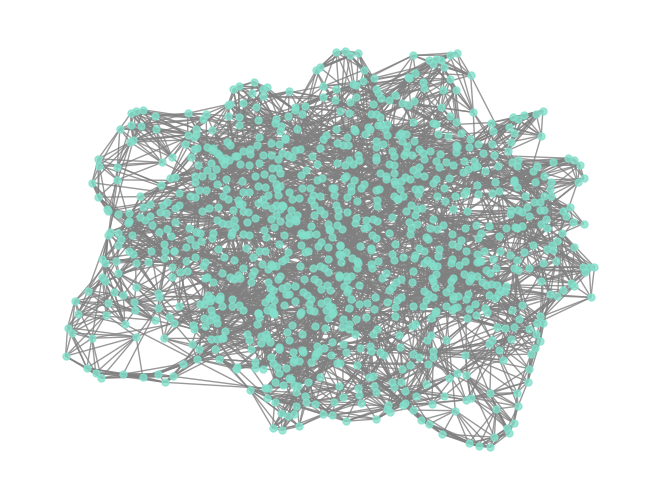

In [14]:
n_swn = 1000
k_swn = 10     #(A node connected to 10 nearest neighbours)
p_rewire_swn = 0.1  #(rewiring probability)

G_smallworld = nx.watts_strogatz_graph(n_swn, k_swn, p_rewire_swn)

# pos = nx.circular_layout(G_smallworld)

print("Properties of Small World Network Model (Watts-Strogatz)")
Characteristics(G_smallworld)
nx.draw(G_smallworld, node_size=25, alpha=0.8, node_color="#84e0cc", edge_color="gray")
plt.show()

#### Preferential Attachment Model (Barabasi-Albert)

Properties of Preferential Attachment Network Model (Barabasi-Albert)
Number of nodes: 1000
Number of edges: 2991
Average clustering coefficient: 0.02977575770827881
Degree distribution (first 10): [106, 104, 57, 50, 42, 41, 38, 36, 33, 33]
Average shortest path length: 3.498966966966967


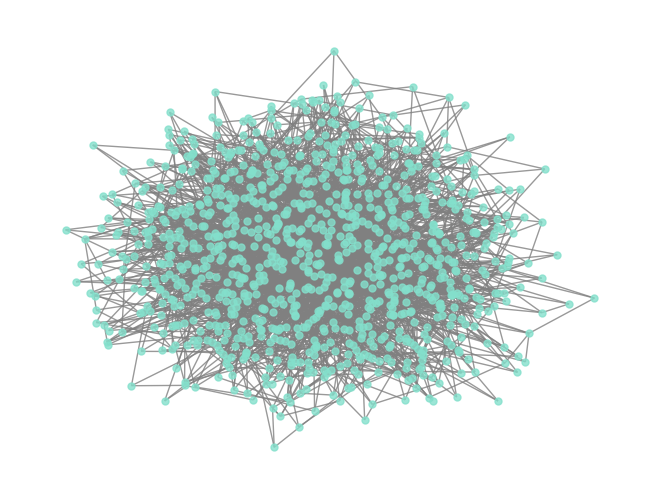

In [15]:
n_pan = 1000
m_pan = 3  #(Number of edges to attach from a new node to existing nodes)
G_preferential = nx.barabasi_albert_graph(n_pan, m_pan)

print("Properties of Preferential Attachment Network Model (Barabasi-Albert)")
Characteristics(G_preferential)

nx.draw(G_preferential, node_size=25, alpha=0.8, node_color="#84e0cc", edge_color="gray")
plt.show()

### Q4 Compute different centrality measures to identify top-N nodes and compute rank correlation coefficient with the ranks obtained by PageRank method.

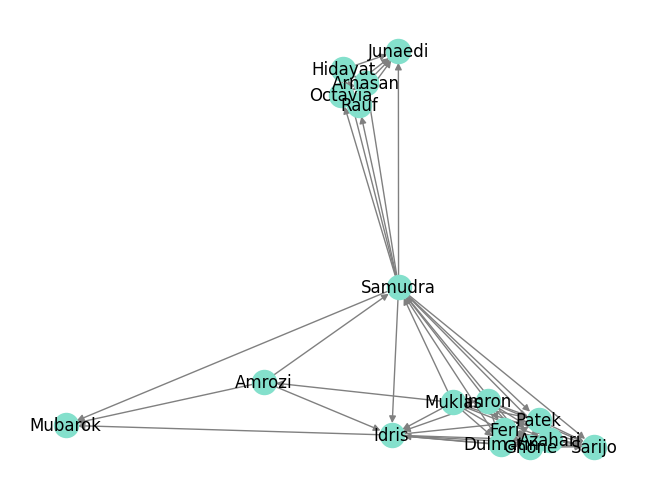

          degree_centrality  betweenness_centrality  eigenvector_centrality  \
Muklas               0.5625                0.000000            2.597247e-21   
Amrozi               0.2500                0.001389            1.924560e-18   
Imron                0.5625                0.000833            1.924560e-18   
Samudra              0.9375                0.080853            1.426099e-15   
Dulmatin             0.5625                0.002470            3.522477e-13   
Idris                0.6250                0.017758            6.543109e-11   
Azahari              0.5625                0.004454            9.736286e-09   
Ghone                0.5625                0.004454            1.208944e-06   
Patek                0.5625                0.004454            1.288416e-04   
Sarijo               0.5625                0.000000            9.999276e-01   
Mubarok              0.1875                0.000000            9.671208e-09   
Feri                 0.3750                0.000000 

,degree_centrality,betweenness_centrality,eigenvector_centrality,closeness_centrality,pagerank
Muklas,12.0,5.0,1.0,1.0,1.0
Amrozi,2.0,11.0,2.5,2.5,2.5
Imron,12.0,10.0,2.5,2.5,2.5
Samudra,17.0,17.0,4.0,5.0,7.0
Dulmatin,12.0,12.0,6.0,7.0,5.0
Idris,16.0,16.0,8.0,11.0,11.0
Azahari,12.0,14.0,11.0,12.0,10.0
Ghone,12.0,14.0,13.0,15.0,12.0
Patek,12.0,14.0,15.0,16.0,14.0
Sarijo,12.0,5.0,17.0,17.0,17.0



Spearman Correlation with PageRank:
degree_centrality         0.064384
betweenness_centrality   -0.054595
eigenvector_centrality    0.958282
closeness_centrality      0.947821
pagerank                  1.000000
Name: pagerank, dtype: float64


In [16]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/SNA Datasets/Bali.txt', sep='\t', header=None, names=['Source', 'Target', 'Weight'])

G = nx.from_pandas_edgelist(df, source='Source', target='Target', edge_attr='Weight', create_using=nx.DiGraph())


G.nodes
nx.draw(G, with_labels = True,  node_color="#84e0cc", edge_color="gray")
plt.show()

# Centrality Measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
closeness_centrality = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

# Dataframe

df = pd.DataFrame({
    'degree_centrality': degree_centrality,
    'betweenness_centrality': betweenness_centrality,
    'eigenvector_centrality': eigenvector_centrality,
    'closeness_centrality': closeness_centrality,
    'pagerank': pagerank
})
print(df)

df = df.rank()
print("Ranked Centrality Measures:")
display(df)

spearman_corr = df.corr(method='spearman')['pagerank']
print("\nSpearman Correlation with PageRank:")
print(spearman_corr)



### Q5 Apply various community detection algorithm(Louvain, Greedy Modularity, and Infomap) on a small real-world network(karate club) and plot the community revealed with different colors. also , compare the result of these alg, Plot bar graph for all the three algorithm and compare the modularity score.

Nodes: 34
Edges: 78


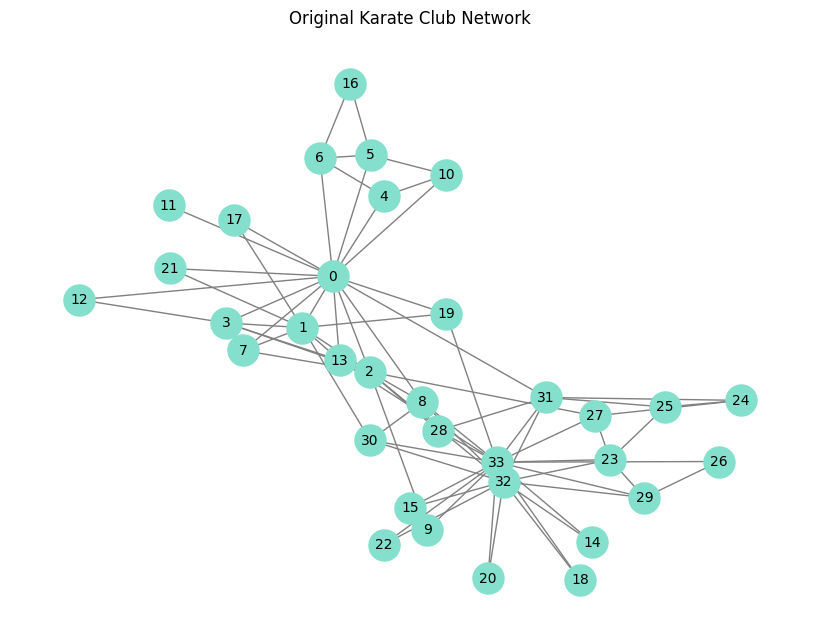

In [17]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.karate_club_graph()

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Visualize the original network
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color='#84e0cc', edge_color='gray', node_size=500, font_size=10)
plt.title("Original Karate Club Network")
plt.show()

In [18]:
!pip install python-louvain
!pip install infomap

Louvain - Number of communities: 4
Fast Greedy (CNM) - Number of communities: 3
Infomap - Number of communities: 3


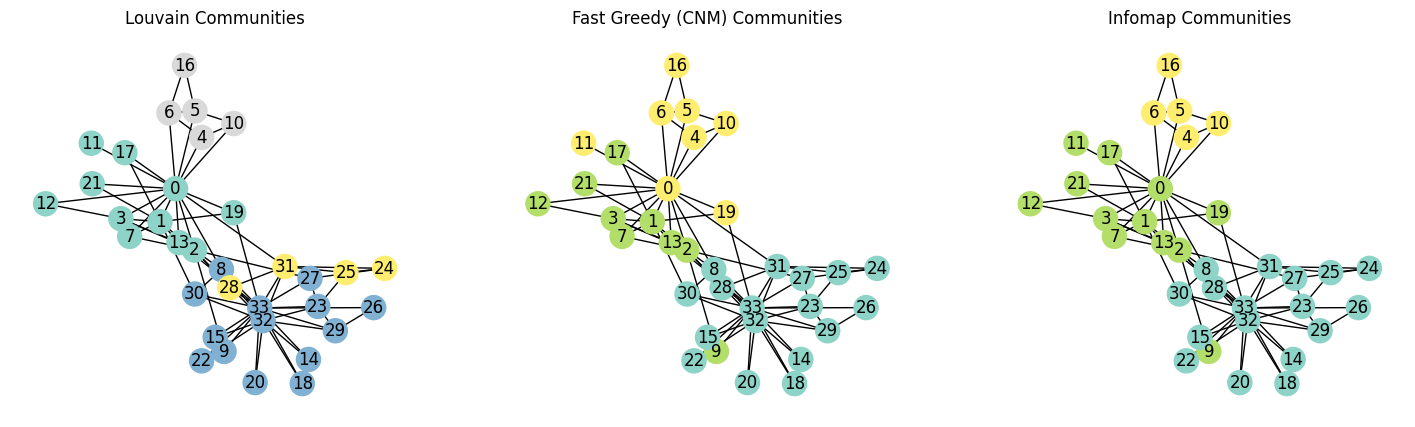

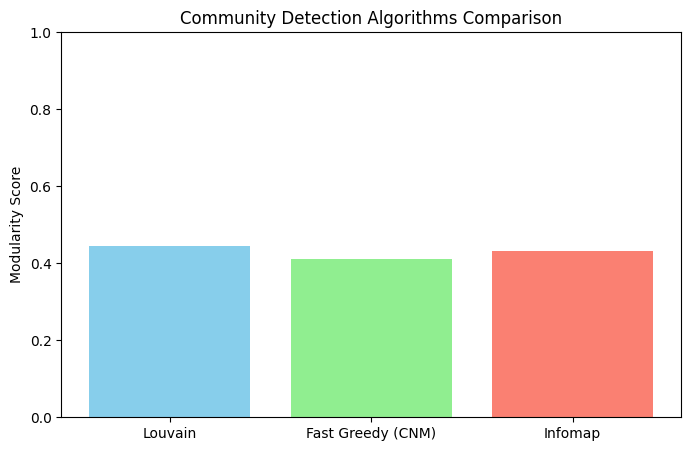

In [19]:
!pip install python-louvain

import networkx as nx
import matplotlib.pyplot as plt

from infomap import Infomap
import numpy as np
import community.community_louvain as community_louvain


G = nx.karate_club_graph()


# 4) Louvain Community Detection

louvain_partition = community_louvain.best_partition(G)  # Use community_louvain.best_partition
louvain_communities_list_of_sets = []
for community_id in set(louvain_partition.values()):
    louvain_communities_list_of_sets.append({node for node, cid in louvain_partition.items() if cid == community_id})
print("Louvain - Number of communities:", len(louvain_communities_list_of_sets))

# Assign colors
louvain_colors = [louvain_partition[node] for node in G.nodes()]


# 4) FAST GREEDY
cnm_communities = list(nx.community.greedy_modularity_communities(G))
print("Fast Greedy (CNM) - Number of communities:", len(cnm_communities))

# Assign colors
cnm_colors = np.zeros(len(G.nodes()))
for i, comm in enumerate(cnm_communities):
    for node in comm:
        cnm_colors[node] = i


# 6) Infomap Algorithm

im = Infomap()
for node in G.nodes():
    im.addNode(node)

for u, v in G.edges():
    im.addLink(u, v)
im.run()

infomap_partition = {node.node_id: node.module_id for node in im.nodes}
infomap_communities_list_of_sets = []
for community_id in set(infomap_partition.values()):
    infomap_communities_list_of_sets.append({node for node, cid in infomap_partition.items() if cid == community_id})

print("Infomap - Number of communities:", len(infomap_communities_list_of_sets))

# Assign colors
infomap_colors = [infomap_partition[node] for node in G.nodes()]

# ------------------------------
# 7) Plot communities
# ------------------------------
pos = nx.spring_layout(G, seed=42)  # layout

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
nx.draw(G, pos, node_color=louvain_colors, with_labels=True, cmap=plt.cm.Set3, node_size=300)
plt.title("Louvain Communities")

plt.subplot(1,3,2)
nx.draw(G, pos, node_color=cnm_colors, with_labels=True, cmap=plt.cm.Set3, node_size=300)
plt.title("Fast Greedy (CNM) Communities")

plt.subplot(1,3,3)
nx.draw(G, pos, node_color=infomap_colors, with_labels=True, cmap=plt.cm.Set3, node_size=300)
plt.title("Infomap Communities")

plt.show()

# ------------------------------
# 8) Compare modularity
# ------------------------------
# Louvain modularity
mod_louvain = community_louvain.modularity(louvain_partition, G) # Use community_louvain.modularity

# CNM modularity
# NetworkX greedy_modularity_communities returns list of sets, modularity can be computed
mod_cnm = nx.community.modularity(G, cnm_communities)

# Infomap modularity (using the list of sets)
mod_infomap = nx.community.modularity(G, infomap_communities_list_of_sets)

# Bar plot
algos = ["Louvain", "Fast Greedy (CNM)", "Infomap"]
mod_scores = [mod_louvain, mod_cnm, mod_infomap]

plt.figure(figsize=(8,5))
plt.bar(algos, mod_scores, color=['skyblue','lightgreen','salmon'])
plt.ylabel("Modularity Score")
plt.title("Community Detection Algorithms Comparison")
plt.ylim(0,1)
plt.show()

### Q6 Simulate diffusion trends for different epidemic models and present results using appropriate visuals.


no display found. Using non-interactive Agg backend


<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

<Figure size 2000x1000 with 0 Axes>

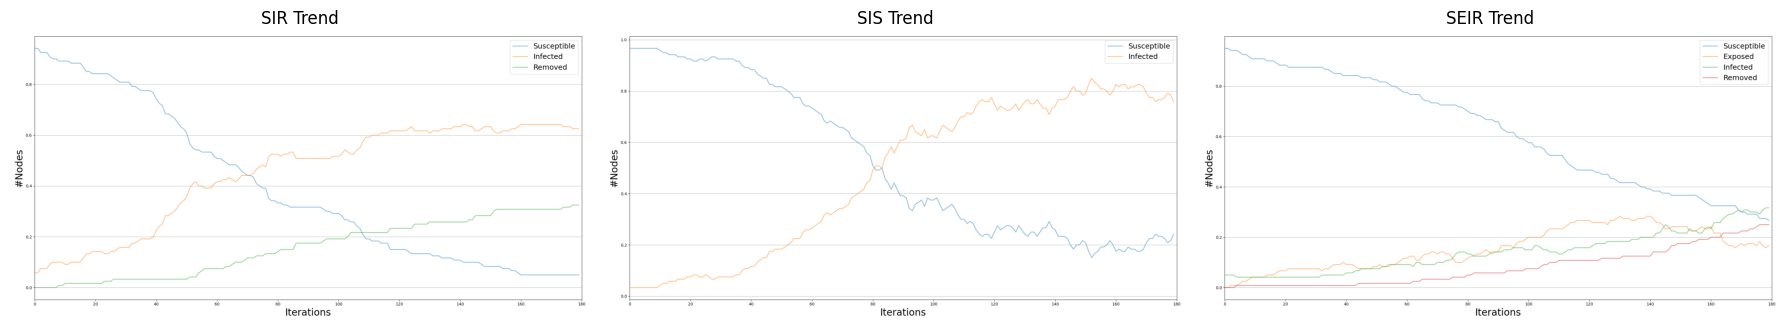

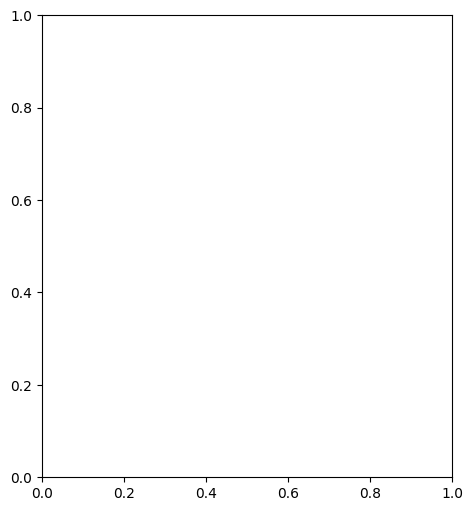

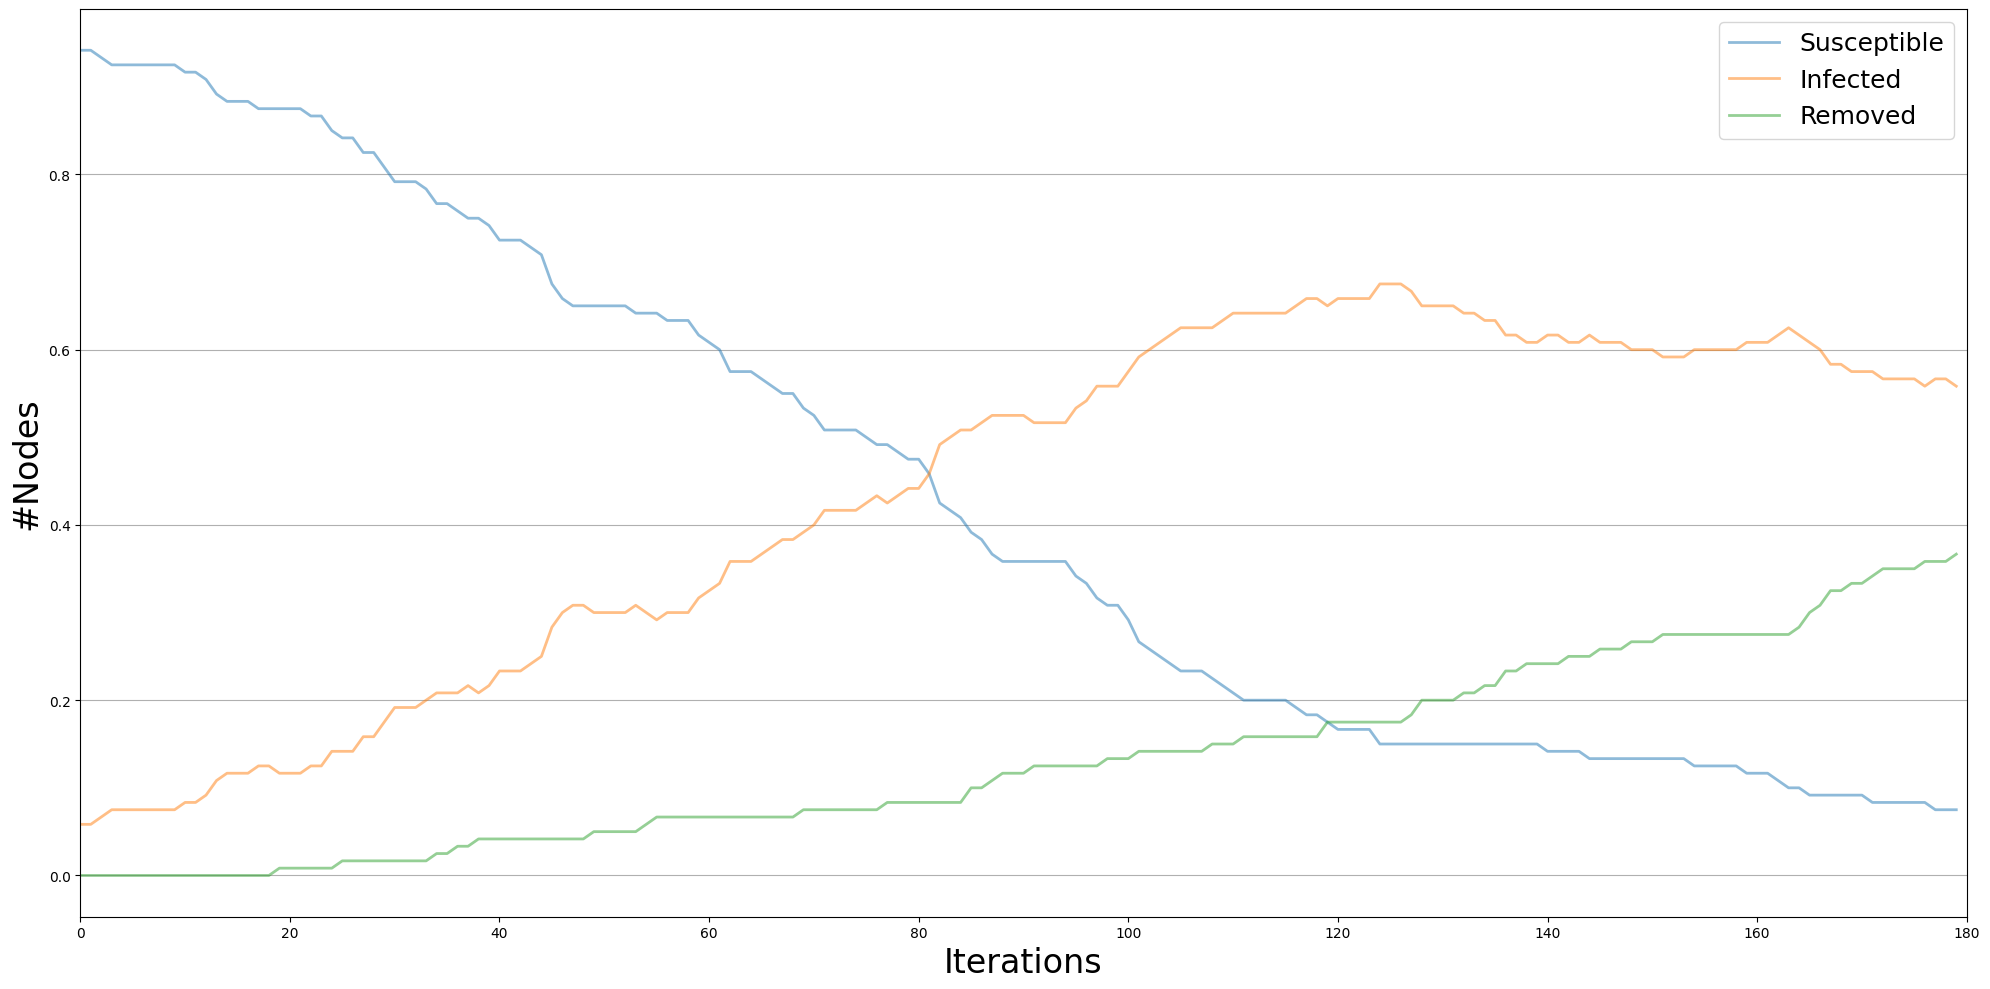

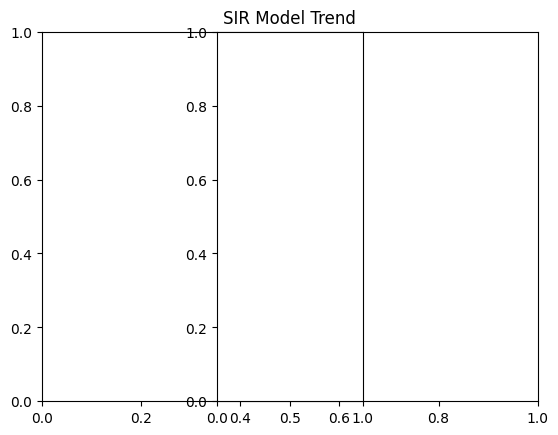

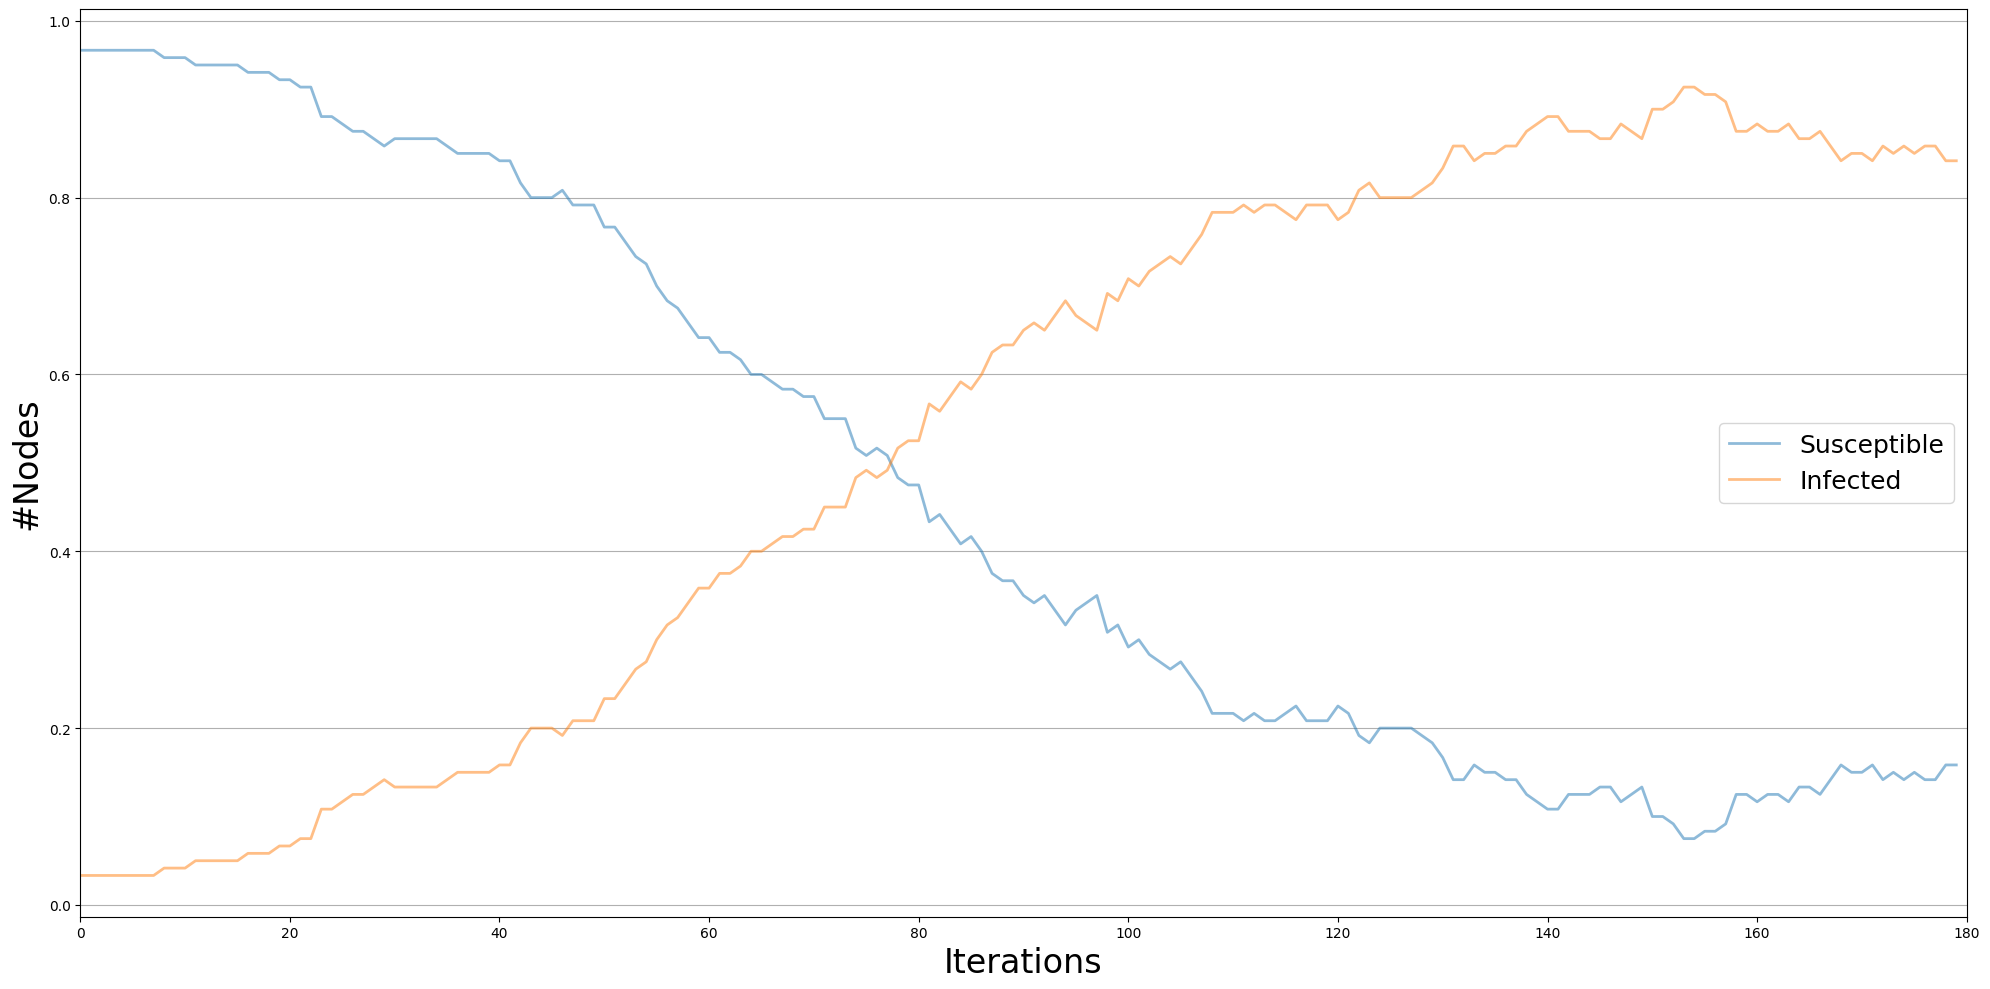

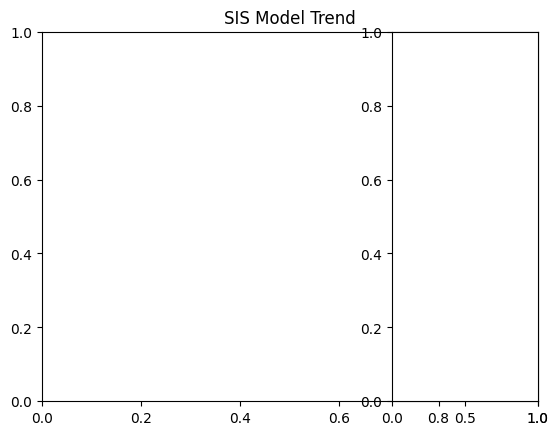

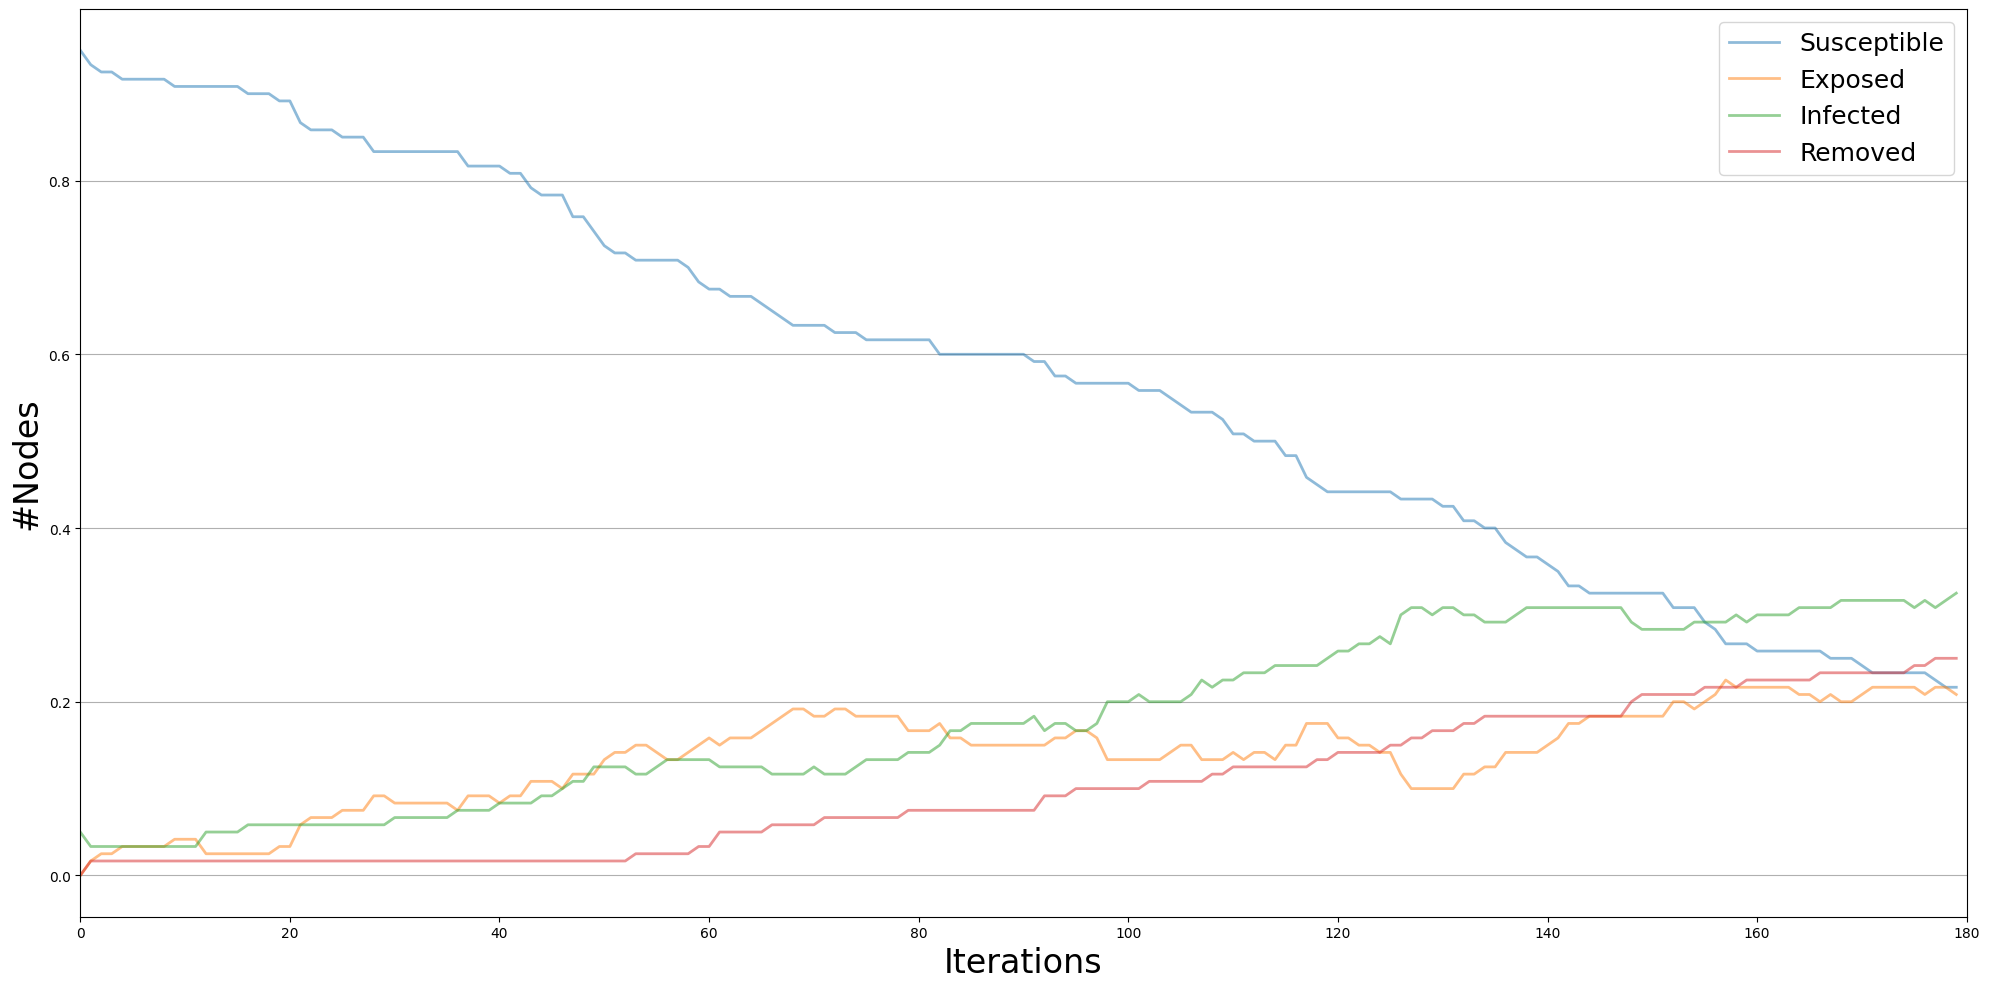

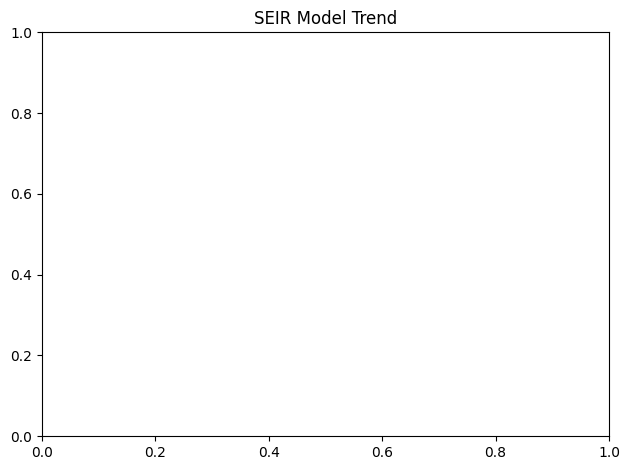

In [21]:
%matplotlib inline
!pip install ndlib

import networkx as nx
import ndlib.models.epidemics as ep
import ndlib.models.ModelConfig as mc
from ndlib.viz.mpl.DiffusionTrend import DiffusionTrend
import matplotlib.pyplot as plt


def simulate(model_obj, config_obj):
    model_obj.set_initial_status(config_obj)
    it = model_obj.iteration_bunch(180)
    tr = model_obj.build_trends(it)
    viz = DiffusionTrend(model_obj, tr)
    return viz

# Network
network = nx.erdos_renyi_graph(120, 0.04)

# SIR
sir = ep.SIRModel(network)
c1 = mc.Configuration()
c1.add_model_parameter("beta", 0.012)
c1.add_model_parameter("gamma", 0.004)
c1.add_model_parameter("percentage_infected", 0.06)
sir_viz = simulate(sir, c1)

# SIS
sis = ep.SISModel(network)
c2 = mc.Configuration()
c2.add_model_parameter("beta", 0.018)
c2.add_model_parameter("lambda", 0.012)
c2.add_model_parameter("percentage_infected", 0.04)
sis_viz = simulate(sis, c2)

# SEIR
seir = ep.SEIRModel(network)
c3 = mc.Configuration()
c3.add_model_parameter("beta", 0.018)
c3.add_model_parameter("gamma", 0.009)
c3.add_model_parameter("alpha", 0.017)
c3.add_model_parameter("percentage_infected", 0.05)
seir_viz = simulate(seir, c3)


plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sir_viz.plot()
plt.title("SIR Model Trend")

plt.subplot(1,3,2)
sis_viz.plot()
plt.title("SIS Model Trend")

plt.subplot(1,3,3)
seir_viz.plot()
plt.title("SEIR Model Trend")

plt.tight_layout()
plt.show()
